# Lab - YOLOv4-Tiny Part 4 - Converting YOLOv4-Tiny to PyTorch + Inference
## E6792 Spring 2026

In this notebook you will evaluate your model on the validation set and convert it to PyTorch for inference.

<font color="red"><strong>TODO:</strong></font>  Insert your training plot here. It should show decreasing training loss and increasing validation mAP.

Insert your plot here, or in a new cell below.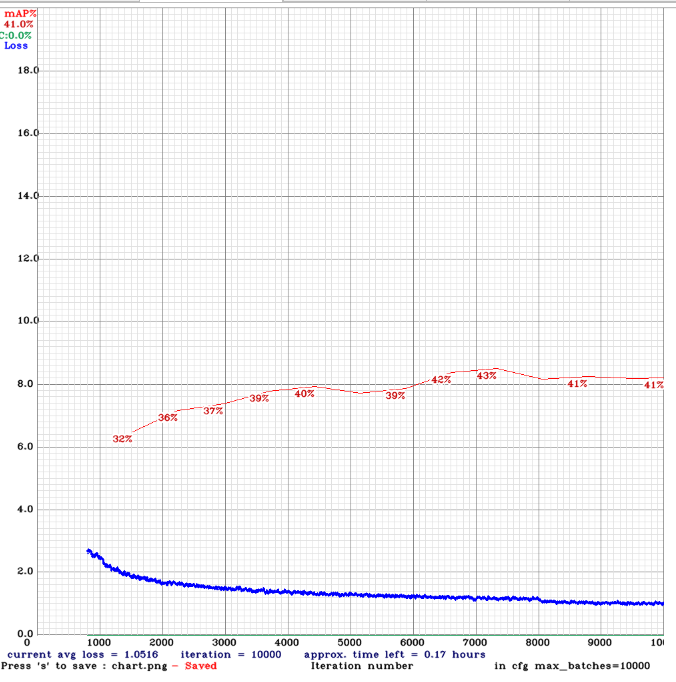

<font color="red"><strong>TODO:</strong></font>  Discuss your training plot and the training process. 

* How long did it take to train?

* What input resolution did you choose?

* What accuracy do you expect your model to achieve based on the training plot?



<font color="red"><strong>TODO:</strong></font>  
## Disscussion ##

The blue curve represents the training loss, which gradually and steadily decreased from approximately 2.6 to approximately 1.05 during the training process. This indicates that the optimization process of this model was stable and converged effectively, achieving successful learning. 
The red curve represents the average precision (mAP) of the verification. As the training progresses, its value increases from approximately 32% to around 41% to 43%. Theoretically, the detection performance should improve as the model undergoes more training iterations. 
However, in the final training stage, the accuracy dropped from 43% to 41%. I believe this is due to the relatively small validation dataset and the randomness of the training process. There will be some fluctuations in mAP. 

#### Q1 ####
22 hours, quite a long time


#### Q2 ####
I chose 416*416

#### Q3 ####
41%–43%


<font color="red"><strong>TODO:</strong></font> Evaluate the validation mAP performance of your model with the following command:

`darknet detector map <data_cfg_path> <model_cfg_path> <best_weights_path>`

`./darknet detector map data_config/person-vehicle-yolov4-tiny.data ../cfg/yolov4-tiny-person-vehicle.cfg backup/yolov4-tiny-person-vehicle_best.weights`

Replace this example output with a screenshot of your evaluation results:
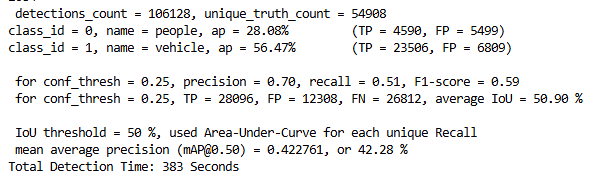
<!-- 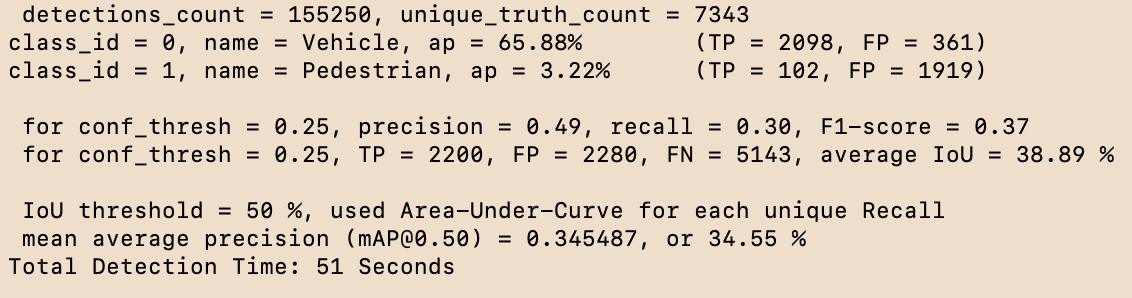 -->


<font color="red"><strong>TODO:</strong></font>  Interpret the results. What is the purpose of this model and which metrics can we consider as "key performance indicators"?

<font color="red"><strong>TODO:</strong></font>  Your answer here.

Next we will visually inspect some inferences on validation frames. 

In [1]:
# complete on VM instance
import os
import random

from darknet_utils.inference import image_inference
from darknet_utils.darknet_to_pytorch import load_darknet_as_pytorch

device = 'cuda'

cfg_path = 'cfg/yolov4-tiny-person-vehicle.cfg'
weights_path = 'weights/yolov4-tiny-person-vehicle_best.weights'
torch_weights_path = 'weights/yolov4-tiny-person-vehicle_best.pt'

validation_dataset_path = 'darknet/data/validation/person-vehicle-yolov4-tiny'

CONF_THRESH = 0.4
NMS_THRESH = 0.4

%load_ext autoreload
%autoreload 2

In [15]:
###################################################
# TODO: Load YOLOv4-Tiny as a PyTorch model with  #
#       load_darknet_as_pytorch()              #
###################################################
from darknet_utils.darknet_to_pytorch import save_pytorch_model

model = load_darknet_as_pytorch(cfg_path, weights_path)
model = model.to(device)
model.eval()
save_pytorch_model(model, torch_weights_path)
###################################################
# END TODO                                        #
###################################################

<font color="red"><strong>TODO:</strong></font>  Visualize inferences on at least three validation frames. Select the frames randomly from the validation set. Ideally the selected frames will be from different videos and therefore visually distinct. You may find it useful to implement the function **image_inference()** in **darknet_utils/inference.py**.


Total validation images: 2683
Running inference on: darknet/data/validation/person-vehicle-yolov4-tiny/13927.jpg


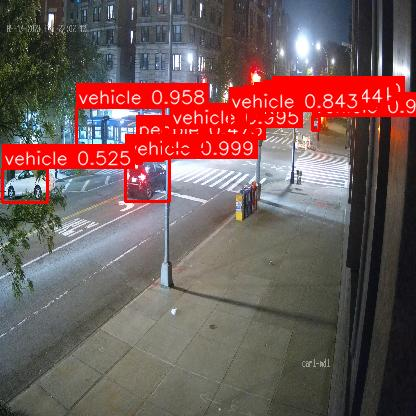

Running inference on: darknet/data/validation/person-vehicle-yolov4-tiny/8892.jpg


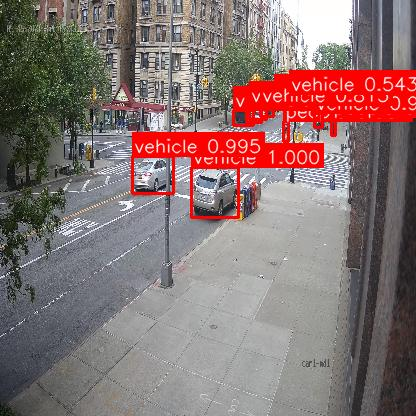

Running inference on: darknet/data/validation/person-vehicle-yolov4-tiny/6915.jpg


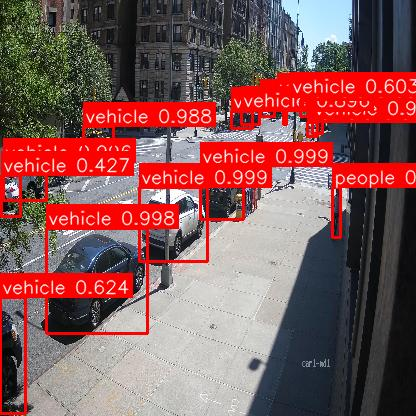

In [13]:
###################################################
# TODO: Visualize inferences on randomly selected #
#       validation frames                         #
###################################################
from collections import defaultdict
from darknet_utils.inference import get_class_names

all_images = []

for root, _, files in os.walk(validation_dataset_path):
    for f in files:
        if f.lower().endswith(('.jpg')):
            all_images.append(os.path.join(root, f))

print("Total validation images:", len(all_images))

selected_images = random.sample(all_images, 3)

for img_path in selected_images:
    print("Running inference on:", img_path)
    image_inference(
        img_path,
        model,
        CONF_THRESH,
        NMS_THRESH,
        class_names
    )


###################################################
# END TODO                                        #
###################################################